In [1]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv("train_cleaned.csv")
test_df = pd.read_csv("test_cleaned.csv")

# 새로운 컬럼 생성
def classify_infertility(row):
    major = []
    minor = []
    
    if row['남성 주 불임 원인'] == 1:
        major.append('남성')
    if row['여성 주 불임 원인'] == 1:
        major.append('여성')
    if row['부부 주 불임 원인'] == 1:
        major.append('부부')
    
    if row['남성 부 불임 원인'] == 1:
        minor.append('남성')
    if row['여성 부 불임 원인'] == 1:
        minor.append('여성')
    if row['부부 부 불임 원인'] == 1:
        minor.append('부부')
    
    major_cause = ', '.join(major) if major else '없음'
    minor_cause = ', '.join(minor) if minor else '없음'
    
    return pd.Series([major_cause, minor_cause])

def aggregate_causes(row):
    causes = []
    
    if row['불임 원인 - 난관 질환'] == 1:
        causes.append('난관 질환')
    if row['불임 원인 - 남성 요인'] == 1:
        causes.append('남성 요인')
    if row['불임 원인 - 배란 장애'] == 1:
        causes.append('배란 장애')
    if row['불임 원인 - 여성 요인'] == 1:
        causes.append('여성 요인')
    if row['불임 원인 - 자궁경부 문제'] == 1:
        causes.append('자궁경부 문제')
    if row['불임 원인 - 자궁내막증'] == 1:
        causes.append('자궁내막증')
    if row['불임 원인 - 정자 농도'] == 1:
        causes.append('정자 농도 문제')
    if row['불임 원인 - 정자 면역학적 요인'] == 1:
        causes.append('정자 면역학적 요인')
    if row['불임 원인 - 정자 운동성'] == 1:
        causes.append('정자 운동성 문제')
    if row['불임 원인 - 정자 형태'] == 1:
        causes.append('정자 형태 문제')

    return ', '.join(causes) if causes else '없음'

def classify_embryo_usage(row):
    usage = []
    
    if row['동결 배아 사용 여부'] == 1:
        usage.append('동결 배아')
    if row['신선 배아 사용 여부'] == 1:
        usage.append('신선 배아')
    if row['기증 배아 사용 여부'] == 1:
        usage.append('기증 배아')
    
    return ', '.join(usage) if usage else '없음'

# 적용
df[['주요 불임 원인', '부차적 불임 원인']] = df.apply(classify_infertility, axis=1)
test_df[['주요 불임 원인', '부차적 불임 원인']] = test_df.apply(classify_infertility, axis=1)

df['불임 원인'] = df.apply(aggregate_causes, axis=1)
test_df['불임 원인'] = test_df.apply(aggregate_causes, axis=1)

df['배아 사용 여부'] = df.apply(classify_embryo_usage, axis=1)
test_df['배아 사용 여부'] = test_df.apply(classify_embryo_usage, axis=1)

# 기존 컬럼 제거
df.drop(columns=['남성 주 불임 원인', '여성 주 불임 원인', '부부 주 불임 원인', '남성 부 불임 원인', '여성 부 불임 원인', '부부 부 불임 원인'], inplace=True)
test_df.drop(columns=['남성 주 불임 원인', '여성 주 불임 원인', '부부 주 불임 원인', '남성 부 불임 원인', '여성 부 불임 원인', '부부 부 불임 원인'], inplace=True)

df.drop(columns=[
    '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인',
    '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인',
    '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태'
], inplace=True)
test_df.drop(columns=[
    '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인',
    '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인',
    '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태'
], inplace=True)

df.drop(columns=['동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부'], inplace=True)
test_df.drop(columns=['동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부'], inplace=True)

# 0만 존재하는 열 삭제
non_zero_columns = df.columns[(df != 0).any()] 
df_c = df[non_zero_columns]
t_non_zero_cols = test_df.columns[(test_df != 0).any()] 
test_df_c = test_df[t_non_zero_cols]

# 결과 저장
df_c.to_csv("join_train.csv", index=False, encoding='utf-8-sig')
test_df_c.to_csv("join_test.csv", index=False, encoding='utf-8-sig')

print(df.columns)
print(len(df.columns))
print(df_c.columns)
print(len(df_c.columns))

Index(['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형',
       '단일 배아 이식 여부', '착상 전 유전 진단 사용 여부', '불명확 불임 원인', '배아 생성 주요 이유',
       '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수',
       'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수',
       '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수',
       '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수',
       '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수',
       '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '난자 기증자 나이', '정자 기증자 나이',
       '대리모 여부', '난자 채취 경과일', '난자 혼합 경과일', '배아 이식 경과일', '임신 성공 여부', '주요 불임 원인',
       '부차적 불임 원인', '불임 원인', '배아 사용 여부'],
      dtype='object')
47
Index(['시술 시기 코드', '시술 당시 나이', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형',
       '단일 배아 이식 여부', '착상 전 유전 진단 사용 여부', '불명확 불임 원인', '배아 생성 주요 이유',
       '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', '총 임신 횟수',
       'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수',
 

In [38]:
X = df_c.drop(["임신 성공 여부"], axis=1)
y = df_c["임신 성공 여부"]

In [39]:
# 빈도 인코딩
X_encoded = X.copy()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    freq_encoding = X[col].value_counts().to_dict()
    X_encoded[col] = X[col].map(freq_encoding)

d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\env\envs\aimers\Lib\

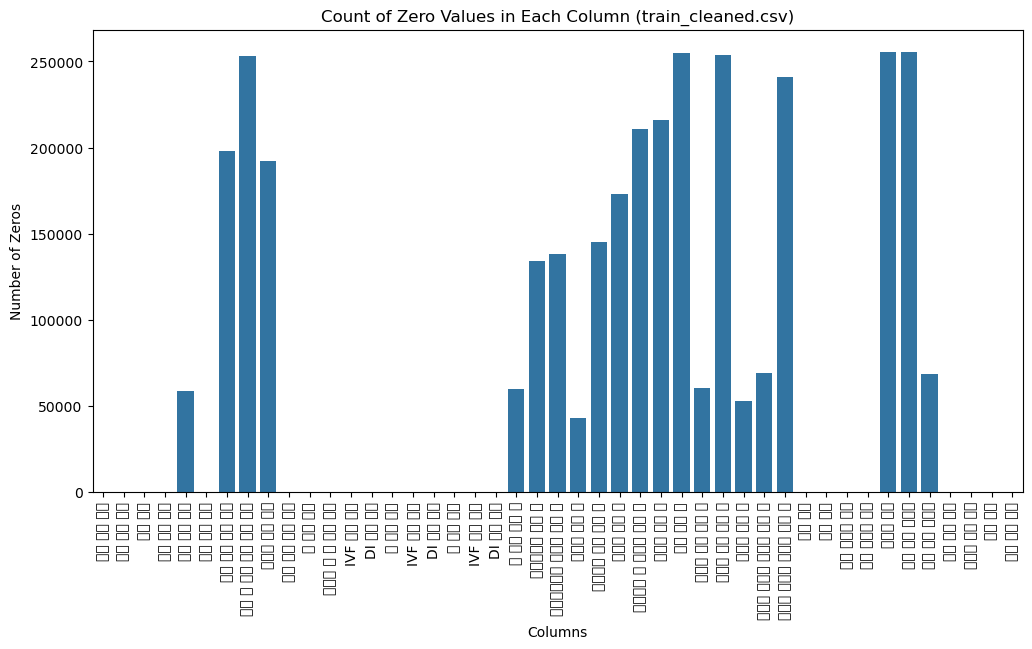

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# # train_cleaned.csv 파일이 있다고 가정
# train_cleaned_file_path = "train_cleaned.csv"

# # 데이터 불러오기
# train_cleaned_df = pd.read_csv(train_cleaned_file_path)

# 각 컬럼에서 0의 개수 세기
zero_counts_cleaned = (X_encoded == 0).sum()

# 0이 하나라도 있는 컬럼만 필터링
#zero_counts_cleaned = zero_counts_cleaned[zero_counts_cleaned > 0]

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x=zero_counts_cleaned.index, y=zero_counts_cleaned.values)
plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Number of Zeros")
plt.title("Count of Zero Values in Each Column (train_cleaned.csv)")
plt.show()


In [41]:
zero_counts_cleaned

시술 시기 코드                 0
시술 당시 나이                 0
시술 유형                    0
특정 시술 유형                 0
배란 자극 여부             58631
배란 유도 유형                 0
단일 배아 이식 여부         197968
착상 전 유전 진단 사용 여부    253155
불명확 불임 원인           192076
배아 생성 주요 이유              0
총 시술 횟수                  0
클리닉 내 총 시술 횟수            0
IVF 시술 횟수                0
DI 시술 횟수                 0
총 임신 횟수                  0
IVF 임신 횟수                0
DI 임신 횟수                 0
총 출산 횟수                  0
IVF 출산 횟수                0
DI 출산 횟수                 0
총 생성 배아 수            59640
미세주입된 난자 수          133960
미세주입에서 생성된 배아 수     138063
이식된 배아 수             42835
미세주입 배아 이식 수        145065
저장된 배아 수            173157
미세주입 후 저장된 배아 수     210585
해동된 배아 수            215966
해동 난자 수             254906
수집된 신선 난자 수          60136
저장된 신선 난자 수         253685
혼합된 난자 수             52941
파트너 정자와 혼합된 난자 수     69212
기증자 정자와 혼합된 난자 수    240837
난자 출처                    0
정자 출처                    0
난자 기증자 나이                0
정